# Imports

In [ ]:
import pandas as pd
import numpy as np
import sys
import os
module_path = os.path.abspath(os.path.join('..', 'src'))
if module_path not in sys.path:
    sys.path.append(module_path)
from sklearn.model_selection import train_test_split
from Autoencoder import Autoencoder 
import matplotlib.pyplot as plt
from KMeans import KMeans

# 1. Autoencoder
Its a type of neural network used to learn efficient data codings in an unsupervised manner. Hence its not limited to linear transformation as it uses non-linear activation functions like `Relu` , `sigmoid` and `tanh`, which make it capture complex relationships between data.
The structure of the Autoencoder in this model is called `Bottleneck Structure` which consists of two main parts:

- `The Encoder`, it compresses the high dimensional input data into a lower dimenional representation.
- `The decoder`, it attempts to reconstruct the original input data from the compressed representation.

# 2. How the model works

Firstly when the model is initialized the weights matrix and bais vector are created using `He initialization`.

### 2.1. He initialization
`He initialization` multiplies random values by $\sqrt{2/n_{in}}$, where $n_{in}$ is the input layer size.
this initialization makes the weights not be too large; which will cause the gradiant to explode(output layers grow really big); and not too small; which results in vanishing the gradient (output shrinks to zero).

### 2.2. Activation functions
Activation functions used are:
- ReLU: Returns $x$ if positive, else 0. Best for hidden layers.
- Sigmoid: Squashes values between 0 and 1. The `np.clip` prevents the math from "breaking" (overflow) if x is too large.
- Squashes values between −1 and 1.

Then there's activation derivative functions that's used to measure the sensitivty of the output the activation functions made, which tells the network how much to change the weights during the backwark pass.

### 2.3. Forward pass
Then comes the forward pass which calculates the $Z$ for each layer:

$$Z = W . X + b$$

And then aplies the activation function on $Z$.

### 2.4. Backward pass

firstly we get the reconstruction error `dA` which we use to calculate the gradient for $Z$ whoc is used to calculate the rest of the gradients.

- Gradients for $Z$: It multiplies the error by the derivative of the activation function. This tells the network how "sensitive" the output was to the raw input of that layer.
- Gradients for Weights ($W$) and Biases ($b$): It uses these sensitivity values to determine exactly how to nudge the weights and biases.
`L2 Regularization` is added during this step. It discourages the weights from becoming too large, which helps prevent the model from simply "memorizing" the training data instead of learning its patterns.

- The gradiant decent is preformed, update the weights and biases


### 2.5. Training

For the learning rate we use a decaying method called `time-based decay` which id used for:

- Speed Up Initial Learning: At the start of training, the model's weights are usually far from the optimal values. A high initial learning rate allows the model to make large, fast updates to get into the right neighborhood quickly.

- Fine-Tuning at the End: As the model approaches the "perfect" settings (the minimum of the loss function), large steps can be harmful. They might cause the model to "overshoot" or bounce back and forth across the optimal point without ever settling down.

- Better Generalization: By slowing down the learning process in later stages, decay helps the model focus on complex patterns and reduces the risk of it simply memorizing noise in the training data (overfitting).

Then we perform forward and backward passes and calculate the mean square loss.


# 3. Implementation

# Data preparetion

In [ ]:
data = pd.read_csv('../data/data.csv')
y = data['diagnosis'].map({'M': 1, 'B': 0}).values
data.drop(columns=['diagnosis', 'id','Unnamed: 32'], inplace=True, errors='ignore')
x = data.copy()
print(x.head())


   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

In [ ]:
# Standardize for pca kmeans and gmm
mean = np.mean(x, axis=0)
std = np.std(x, axis=0)
x_standardized = (x - mean) / (std + 1e-8) #add small value to avoid division by zero

In [ ]:
# normalized data for autoencoder
min = np.min(x, axis=0)
max = np.max(x, axis=0)
x_normalized = (x - min) / (max - min + 1e-8) #add small value to avoid division by zero
x_normalized.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431016,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186815,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595


### data standardization and normalization


In [ ]:
layer_sizes = [30, 25, 20, 15, 10, 15, 20, 25, 30]
activation_functions = ['relu', 'relu', 'relu', 'tanh', 
               'relu', 'relu', 'relu', 'sigmoid']
ae = Autoencoder(layer_sizes, activation_functions)

In [ ]:
loss_history = ae.train(x_normalized.values,epochs=400)

Epoch 0, Loss: 0.0552, Learning Rate: 0.1000
Epoch 10, Loss: 0.0134, Learning Rate: 0.0909
Epoch 20, Loss: 0.0112, Learning Rate: 0.0833
Epoch 30, Loss: 0.0096, Learning Rate: 0.0769
Epoch 40, Loss: 0.0087, Learning Rate: 0.0714
Epoch 50, Loss: 0.0078, Learning Rate: 0.0667
Epoch 60, Loss: 0.0071, Learning Rate: 0.0625
Epoch 70, Loss: 0.0069, Learning Rate: 0.0588
Epoch 80, Loss: 0.0064, Learning Rate: 0.0556
Epoch 90, Loss: 0.0062, Learning Rate: 0.0526
Epoch 100, Loss: 0.0061, Learning Rate: 0.0500
Epoch 110, Loss: 0.0060, Learning Rate: 0.0476
Epoch 120, Loss: 0.0058, Learning Rate: 0.0455
Epoch 130, Loss: 0.0058, Learning Rate: 0.0435
Epoch 140, Loss: 0.0056, Learning Rate: 0.0417
Epoch 150, Loss: 0.0055, Learning Rate: 0.0400
Epoch 160, Loss: 0.0055, Learning Rate: 0.0385
Epoch 170, Loss: 0.0054, Learning Rate: 0.0370
Epoch 180, Loss: 0.0054, Learning Rate: 0.0357
Epoch 190, Loss: 0.0054, Learning Rate: 0.0345
Epoch 200, Loss: 0.0054, Learning Rate: 0.0333
Epoch 210, Loss: 0.0053,

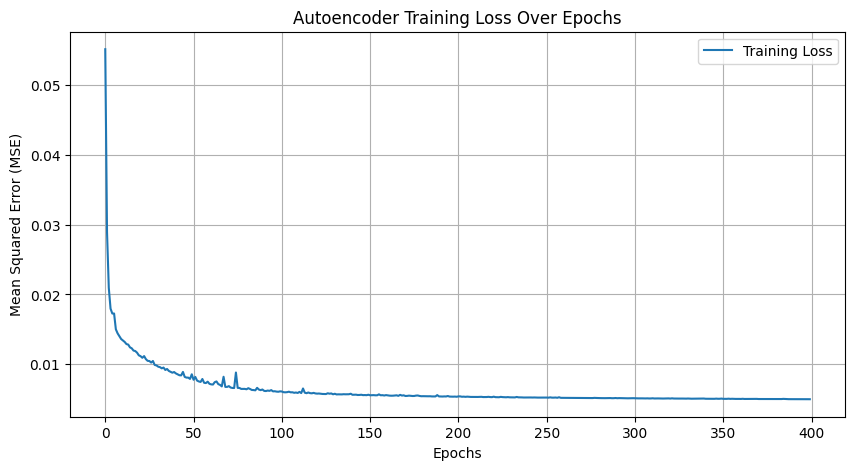

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss')
plt.title('Autoencoder Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()